# BoE Earnings Insights — Group 9

Topic modelling, sentiment analysis, and LLM summarisation of **HSBC** and **Barclays** earnings-call transcripts and analyst Q&A.

**Employer project with the Bank of England | Cambridge Data Science Career Accelerator | 2026**

**Kernel:** select **Python 3.12 (BoE Earnings)** (`boe-earnings-py312`) — local `.venv` in this workspace.

**Research question:** do quarterly earnings announcements and analyst Q&A carry a leading signal about a firm's prudential condition that reported financial metrics alone don't capture?

**Pipeline:** BERTopic → FinBERT + LDSA → metric-level summarisation → refined topics · **Evaluation:** temporal · peer · structured-vs-unstructured

**Docs map:** [`../docs/README.md`](../docs/README.md) · [Assignment 1 Google Doc](https://docs.google.com/document/d/10211H1XyqjrHAKa_ikN5uuYuyTPrDPteUXeQl-QJJlY/edit?usp=sharing) · [GitHub Project roadmap](https://github.com/users/susanavenda/projects/3/views/2)



## Stage 0 — Setup and dashboard style helpers


In [46]:
## @title 0.1 Install / import dependencies
# Core
import pandas as pd
import numpy as np
import re
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# NLP / preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
try:
    nltk.download('punkt_tab', quiet=True)
except Exception:
    pass

# Topic modelling
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import gensim
from gensim import corpora
from gensim.models import LdaModel

# Sentiment / financial NLP
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Viz
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

pd.set_option('display.max_colwidth', 200)
sns.set_style('whitegrid')
REPO_ROOT = Path('..') if (Path('..') / 'data' / 'raw' / 'transcripts').exists() and not Path('data/raw/transcripts').exists() else Path('.')
print('Imports OK')
print('REPO_ROOT =', REPO_ROOT.resolve())


Imports OK
REPO_ROOT = /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace


In [47]:
from pathlib import Path

# Project root (notebook lives in notebooks/)
ROOT = Path('..').resolve()
if not (ROOT / 'data').exists():
    ROOT = Path('.').resolve()
TRANSCRIPT_ROOT = ROOT / 'data' / 'raw' / 'transcripts'
STRUCTURED_ROOT = ROOT / 'data' / 'structured'
PROCESSED_ROOT = ROOT / 'data' / 'processed'
DOCS_ROOT = ROOT / 'docs'
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)

## @title 0.2 Style helpers (section_header / insight / kpi_row / display_table / _show_plt)
# Dashboard helpers — same visual pattern as the Week 9&10 topic-project notebook

NAVY   = "#0B1F3A"
BLUE   = "#1565A8"
LBLUE  = "#4FA8E0"
AMBER  = "#BF8F00"
GREEN  = "#2E7D32"
RED    = "#B33A2E"
BG     = "#0E1626"
PANEL  = "#152238"
TEXT   = "#E8EEF7"
MUTED  = "#9FB3C8"
BORDER = "#22314A"

_fig_counter, _table_counter = [0], [0]

def _show_plt(fig, title=""):
    """Styled matplotlib figure with numbered caption."""
    _fig_counter[0] += 1
    label = f"Figure {_fig_counter[0]}" + (f" — {title}" if title else "")
    fig.patch.set_facecolor(BG)
    for ax in fig.axes:
        ax.set_facecolor(PANEL)
        ax.tick_params(colors=MUTED)
        ax.xaxis.label.set_color(TEXT)
        ax.yaxis.label.set_color(TEXT)
        ax.title.set_color(TEXT)
        for spine in ax.spines.values():
            spine.set_color(BORDER)
    display(HTML(
        f'<p style="font-family:Inter,sans-serif;font-size:11px;color:{MUTED};margin:8px 0 2px">{label}</p>'
    ))
    display(fig)
    plt.close(fig)

def section_header(title, subtitle=None, colour=LBLUE):
    sub_html = (
        f'<p style="margin:6px 0 0;font-size:13px;color:{MUTED};font-family:Inter,sans-serif">{subtitle}</p>'
        if subtitle else ""
    )
    display(HTML(
        f'<div style="border-bottom:2px solid {colour};padding-bottom:10px;margin:28px 0 18px">'
        f'<h2 style="margin:0;font-size:18px;font-weight:700;color:{TEXT};font-family:Inter,sans-serif">{title}</h2>'
        f'{sub_html}</div>'
    ))

def insight(text, kind="info", colour=None):
    if colour is None:
        colour = {"info": LBLUE, "key": GREEN, "warn": AMBER}.get(kind, LBLUE)
    display(HTML(
        f'<div style="border-left:3px solid {colour};background:{PANEL};padding:12px 16px;'
        f'border-radius:0 6px 6px 0;margin:12px 0">'
        f'<p style="margin:0;font-family:Inter,sans-serif;font-size:13px;color:{TEXT};line-height:1.7">{text}</p>'
        f'</div>'
    ))

def kpi_row(items):
    cards = ""
    for item in items:
        if len(item) == 4:
            label, value, sub, pos = item
            dc = GREEN if pos else RED
        else:
            label, value, sub = item
            dc = MUTED
        cards += (
            f'<div style="background:{PANEL};border:1px solid {BORDER};border-radius:8px;padding:16px 20px;'
            f'flex:1;min-width:140px">'
            f'<p style="margin:0 0 4px;font-size:11px;color:{MUTED};font-family:Inter,sans-serif;font-weight:600;'
            f'text-transform:uppercase;letter-spacing:.05em">{label}</p>'
            f'<p style="margin:0;font-size:24px;font-weight:700;color:{TEXT};font-family:Inter,sans-serif">{value}</p>'
            f'<p style="margin:4px 0 0;font-size:11px;color:{dc};font-family:Inter,sans-serif">{sub}</p>'
            f'</div>'
        )
    display(HTML(f'<div style="display:flex;gap:12px;flex-wrap:wrap;margin:12px 0">{cards}</div>'))

def display_table(df, title=None, max_rows=15):
    _table_counter[0] += 1
    label = f"Table {_table_counter[0]}" + (f" — {title}" if title else "")
    cols = list(df.columns)
    header = "".join(
        f'<th style="padding:8px 14px;text-align:left;color:{LBLUE};font-weight:600;'
        f'border-bottom:1px solid {BORDER};font-family:Inter,sans-serif;font-size:12px">{c}</th>'
        for c in cols
    )
    rows_html = ""
    for i, (_, row) in enumerate(df.head(max_rows).iterrows()):
        bg = PANEL if i % 2 == 0 else "#1A2D4A"
        cells_html = "".join(
            f'<td style="padding:7px 14px;font-family:Inter,sans-serif;font-size:12px;color:{TEXT}">{v}</td>'
            for v in row.values
        )
        rows_html += f'<tr style="background:{bg}">{cells_html}</tr>'
    display(HTML(
        f'<p style="font-family:Inter,sans-serif;font-size:11px;color:{MUTED};margin:12px 0 4px">{label}</p>'
        f'<div style="overflow-x:auto;border-radius:8px;border:1px solid {BORDER}">'
        f'<table style="border-collapse:collapse;width:100%;background:{BG}">'
        f'<thead><tr>{header}</tr></thead><tbody>{rows_html}</tbody></table></div>'
    ))

section_header("Stage 0 — Setup", "Imports and dashboard helpers loaded")
kpi_row([
    ("Banks", "2", "HSBC · Barclays"),
    ("Pipeline", "4 stages", "Topics · Sentiment · Summaries · Refine"),
    ("Baselines", "3", "Temporal · Peer · Structured"),
])
insight("Style helpers loaded. Use section_header / insight / kpi_row / display_table / _show_plt.", kind="info")



## Stage 1 — Data: transcripts → analyst Q&A corpus

Discover local PDFs and Excel packs, extract text, segment speakers (HSBC + Barclays patterns), and build the analyst-turn modelling corpus.


In [48]:
## @title 1.1 Discover transcript PDFs + structured packs
section_header('Stage 1.1 — Transcript discovery', 'Local samples under data/raw/transcripts/ and data/structured/')

TRANSCRIPT_DIRS = [TRANSCRIPT_ROOT]
STRUCTURED_DIRS = [STRUCTURED_ROOT]
BANKS = ['hsbc', 'barclays']

transcript_files = []
for d in TRANSCRIPT_DIRS:
    if d.exists():
        transcript_files.extend(sorted(d.rglob('*.pdf')))

seen, uniq = set(), []
for f in transcript_files:
    key = str(f.resolve()) if f.exists() else str(f)
    if key not in seen:
        seen.add(key)
        uniq.append(f)
transcript_files = uniq

structured_files = []
for d in STRUCTURED_DIRS:
    if d.exists() and d.is_dir():
        structured_files.extend(sorted(d.rglob('*.xlsx')))
        structured_files.extend(sorted(d.rglob('*.xls')))

print(f'Found {len(transcript_files)} transcript PDFs')
for f in transcript_files:
    print(' -', f)

print(f'\nFound {len(structured_files)} structured Excel packs')
for f in structured_files:
    print(' -', f)

kpi_row([
    ('PDFs found', str(len(transcript_files)), 'data/raw/transcripts/'),
    ('HSBC PDFs', str(sum(1 for f in transcript_files if 'hsbc' in str(f).lower())), 'files'),
    ('Barclays PDFs', str(sum(1 for f in transcript_files if 'barclays' in str(f).lower())), 'files'),
    ('Excel packs', str(len(structured_files)), 'data/structured/'),
])
insight(
    'Re-run 1.2→2.2 after adding PDFs. Use Excel packs in Stage 6.3 (structured vs unstructured).',
    kind='key',
)



Found 13 transcript PDFs
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2025-fy-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2025-q1-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2025-q2-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2025-q3-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2026-q1-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2026-q2-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/hsbc/2025-1q-investors-analysts-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/tr

In [49]:
## @title 1.2 Extract text from PDFs
import pdfplumber

def extract_transcript_text(pdf_path):
    """Extract raw text from an earnings-call transcript PDF."""
    text = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text.append(page_text)
    return '\n'.join(text)

raw_by_file = {}
for f in transcript_files:
    raw_by_file[f] = extract_transcript_text(f)

kpi_row([
    ('PDFs extracted', str(len(raw_by_file)), 'pdfplumber'),
    ('Total chars', f"{sum(len(t) for t in raw_by_file.values()):,}", 'raw text'),
])
if raw_by_file:
    sample_path = next(iter(raw_by_file))
    insight(f'Sample preview — {sample_path.name} ({len(raw_by_file[sample_path]):,} chars)', kind='key')
    print(raw_by_file[sample_path][:800])


Investor Relations
Barclays FY 2025 Results and Progress and Targets Update
10 February 2026
Q&A transcript (amended in places to improve accuracy and readability)
Kian Abouhossein, JP Morgan
Two questions. The �rst question is on the capital return of over £15 billion. If you could just put
this in context of capacity to support investment and growth. How should we think about this
capacity that you're outlining? It looks like there's quite a bit of bufer. So we would like to
understand that.
And then secondly, you're one of the few CEOs who actually discusses ledgers and middle o�ce
integration, which is not a hot topic. But trying to understand a little bit the investment phase,
which has stepped up in 2026 signi�cantly and you're going from £1.1 billion to £2.3 billion of
investments. 


### Stage 1.3 — Speaker segmentation

HSBC turns look like `NAME, FIRM:` / `NAME, ROLE:`. Barclays Q&A PDFs use `Name, Firm` blocks. Tune the regex on a real file from `data/raw/transcripts/`.



In [50]:
## @title 1.3 Speaker segmentation helpers
section_header('Stage 1.3 — Speaker segmentation')

# HSBC: "NAME, ROLE:" or "NAME:"
HSBC_SPEAKER = re.compile(
    r'^([A-Z][A-Z\.\-\' ]{1,40})(?:,\s*([A-Z][A-Z0-9 &\.\-\'/]{1,60}))?:\s*',
    re.MULTILINE,
)
# Barclays: "Name, Firm" on its own line (no colon)
BARCLAYS_SPEAKER = re.compile(
    r'^([A-Z][A-Za-z\.\-\' ]+?),\s+([A-Za-z0-9 &\.\-\'/]+)\s*$',
    re.MULTILINE,
)

SELL_SIDE_FIRMS = [
    'Goldman Sachs', 'Morgan Stanley', 'JPMorgan', 'JP Morgan', 'Citi', 'Citigroup',
    'UBS', 'Barclays', 'HSBC', 'Deutsche Bank', 'Bank of America', 'BofA', 'RBC',
    'Jefferies', 'Jeferies', 'Autonomous', 'KBW', 'Berenberg', 'Exane', 'BNP Paribas',
    'Mediobanca', 'CICC', 'China Securities', 'Deutsche Numis', 'Numis',
]
MGMT_HINTS = [
    'group ceo', 'group cfo', 'group chief', 'chief executive', 'finance director',
    'investor relations', 'group treasurer', 'chief financial',
]

def infer_bank(path):
    s = str(path).lower()
    if 'hsbc' in s:
        return 'hsbc'
    if 'barclays' in s:
        return 'barclays'
    return 'unknown'

def infer_quarter(path):
    name = Path(path).stem.lower()
    m = re.search(r'(20\d{2}).*?(q[1-4]|[1-4]q|interim|annual|fy|h1)', name)
    if not m:
        return Path(path).stem
    y, p = m.group(1), m.group(2)
    mapping = {
        '1q': 'q1', '2q': 'q2', '3q': 'q3', '4q': 'q4',
        'fy': 'annual', 'h1': 'interim',
    }
    return f"{y}-{mapping.get(p, p)}"

def classify_role(firm, bank):
    fl = (firm or '').lower()
    if any(h in fl for h in MGMT_HINTS):
        return 'management'
    if any(f.lower() in fl for f in SELL_SIDE_FIRMS if f.lower() != bank.lower()):
        return 'analyst'
    return 'management'

def segment_transcript(text, bank_name):
    """Split transcript into (speaker, firm, role, text) turns — HSBC + Barclays layouts."""
    matches = list(HSBC_SPEAKER.finditer(text))
    if len(matches) < 5:
        matches = list(BARCLAYS_SPEAKER.finditer(text))

    turns = []
    for i, m in enumerate(matches):
        speaker = m.group(1).strip()
        firm = (m.group(2) or '').strip()
        if len(speaker) > 45 or len(firm) > 60:
            continue
        if speaker.lower().startswith(('and ', 'in ', 'we ', 'the ', 'information ', 'finally ')):
            continue
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        turn_text = text[start:end].strip()
        turn_text = re.sub(r'\n\d+\nInvestor Relations\n?', '\n', turn_text)
        if len(turn_text) < 20:
            continue
        turns.append({
            'speaker': speaker,
            'firm': firm,
            'role': classify_role(firm, bank_name),
            'text': turn_text,
        })
    return pd.DataFrame(turns)

all_turns = []
for path, raw in raw_by_file.items():
    bank = infer_bank(path)
    df = segment_transcript(raw, bank)
    if df.empty:
        continue
    df['bank'] = bank
    df['quarter'] = infer_quarter(path)
    df['source'] = Path(path).name
    all_turns.append(df)

all_turns_df = pd.concat(all_turns, ignore_index=True) if all_turns else pd.DataFrame()
kpi_row([
    ('Turns', str(len(all_turns_df)), 'speaker segments'),
    ('Analyst', str(int((all_turns_df['role'] == 'analyst').sum()) if len(all_turns_df) else 0), 'Q&A side'),
    ('Management', str(int((all_turns_df['role'] == 'management').sum()) if len(all_turns_df) else 0), 'bank side'),
])
display_table(all_turns_df[['bank', 'quarter', 'speaker', 'firm', 'role']].head(12), title='Sample speaker turns')


bank,quarter,speaker,firm,role
barclays,2025-annual,Kian Abouhossein,JP Morgan,analyst
barclays,2025-annual,Guy Stebbings,BNP Paribas,analyst
barclays,2025-annual,Ben Toms,RBC,analyst
barclays,2025-annual,Tim Piechowski,ACR,management
barclays,2025-annual,Andrew Coombs,Citi,analyst
barclays,2025-annual,Then on the US Consumer Bank,I just wanted to understand some of the moving parts because,management
barclays,2025-annual,Perlie Mong,Bank of America,analyst
barclays,2025-annual,Chris Hallam,Goldman Sachs,analyst
barclays,2025-annual,Consumer Bank and customer service,you can't leave pieces of this undone.,management
barclays,2025-annual,Mike Holton,BNY Newton,management


### Stage 1.4 — Analyst Q&A corpus

For topic modelling we want **analyst questions** specifically — challenge and risk language show up there first.


In [51]:
## @title 1.4 Text cleaning
section_header('Stage 1.4 — Analyst Q&A corpus')

def clean_text(text):
    """Lowercase, remove numbers, tokenise, drop stopwords — light clean that keeps financial terms."""
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return ' '.join(tokens)

def build_corpus(all_turns_df):
    """Filter to analyst turns, clean, and keep bank/quarter metadata."""
    qa_df = all_turns_df[all_turns_df['role'] == 'analyst'].copy()
    qa_df['clean_text'] = qa_df['text'].apply(clean_text)
    qa_df = qa_df[qa_df['clean_text'].str.split().str.len() > 3]
    return qa_df.reset_index(drop=True)

corpus_df = build_corpus(all_turns_df)

PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
all_turns_df.to_csv(PROCESSED_ROOT / 'all_turns.csv', index=False)
corpus_df.to_csv(PROCESSED_ROOT / 'corpus_analyst.csv', index=False)

kpi_row([
    ('Analyst turns', str(len(corpus_df)), 'after clean filter'),
    ('HSBC', str(int((corpus_df['bank'] == 'hsbc').sum())), 'docs'),
    ('Barclays', str(int((corpus_df['bank'] == 'barclays').sum())), 'docs'),
    ('Sources', str(corpus_df['source'].nunique()), 'PDF files'),
])
display_table(
    corpus_df[['bank', 'quarter', 'speaker', 'firm', 'clean_text']].head(10),
    title='Analyst corpus preview',
)
insight(
    f'corpus_df ready — {len(corpus_df)} analyst turns from {corpus_df["source"].nunique()} PDFs. '
    'Saved to data/processed/. Spot-check one HSBC + one Barclays speaker table before Stage 2.',
    kind='key',
)





bank,quarter,speaker,firm,clean_text
barclays,2025-annual,Kian Abouhossein,JP Morgan,two questions question capital return billion could put context capacity support investment growth think capacity outlining looks like quite bit bufer would like understand secondly one ceos actually discusses ledgers middle integration hot topic trying understand little bit investment phase stepped going billion billion investments focus think post basically respect venkatakrishnan anna want start capital come back one
barclays,2025-annual,Guy Stebbings,BNP Paribas,question capital terms targets got target think talked sort running top end range throughout plan given plan post pillar changes given constructive tone regulator wondering need see sort potentially move lower range sort formal way running business getting pillar change regulator assume got pretty good visibility expecting things land expect maybe could help sort frame think means capital return rote targets second question mortgage book uk referred headwind half year check terms headwind sort gross headwind mindful kensington sort book might able ofset higher ltv higher margin business coming kind frame headwind thank anna cross one go back beginning said carrying pillar advance irb implementation expect us operate top range towards top range still saying diferent expect pillar ofset get basel irb know right trying every single part plan put control want distribution plan underpinned things ca put course timing regulatory change certainty change saying us short term planning assumption throughout plan top end range obviously way think distributions way calculate rote get beyond implementation clarity course review think within range still think range right range barclays point time regulatory clarity want plan control reason mortgages talking gross impact relates mortgages written end beginning remember coming covid stamp duty holiday mortgage market substantial
barclays,2025-annual,Ben Toms,RBC,first one private banking wealth management products currently missing premier banking proposition easy build secondly continue uk loan book uk retail banks continue surprise upside loan book growth relative gdp think guidance loan growth cagr driving growth excess gdp outlook volumes mortgage market next couple years thank venkatakrishnan let start got pretty big complete product suite couple gaps product suite missing sips junior isas coming online put higher level looking starting end spectrum got direct investment used call smart investor basically investment buying stocks bonds
barclays,2025-annual,Andrew Coombs,Citi,investment bank look targets previously greater target circa cost income ratio circa assuming change primarily due fx perhaps could secondly go back two years think original plan lot revenue growth assumed come market share gains actually assumed fairly wallet actually materialised much better wallet expected market share perhaps could also talk competitive dynamics played versus thought two years ago fed assumptions well
barclays,2025-annual,Perlie Mong,Bank of America,thinking income guidance group level greater cagr within obviously investment bank probably us consumer bank uk part also growing volumes greater trying think imply margins terms product margin would expect income growth coming volume side basically past point deposit margin growing substantially hedge obviously probably bit higher hedges coming think margin piece number one number two sounds like investment bank rwas going stay relatively still expect come group roughly speaking much investment bank cost guidance group level modestly growing suggests investment bank getting much cost either trying think decided context obviously investment bank probably one businesses performed expectations last cycle increasingly questions us peers investing putting capital behind investment bank would choose anna cross think product margin uk think question look bit go see go structural hedge slide please thank slide as

## Stage 2 — Topic modelling (BERTopic)

Embed turns with a sentence-transformer, cluster with HDBSCAN, extract topic representations. Themes are data-driven after feature engineering.


In [52]:
## @title 2.1 Fit BERTopic
section_header('Stage 2.1 — BERTopic')
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Small transcript corpus → keep clusters modest so HDBSCAN still finds themes
min_topic_size = max(4, min(8, max(4, len(corpus_df) // 20)))

topic_model = BERTopic(
    embedding_model=embedding_model,
    min_topic_size=min_topic_size,
    calculate_probabilities=True,
    verbose=True,
)

topics, probs = topic_model.fit_transform(corpus_df['clean_text'].tolist())
corpus_df['topic'] = topics
corpus_df.to_csv(PROCESSED_ROOT / 'corpus_analyst.csv', index=False)

topic_info = topic_model.get_topic_info()
topic_info.to_csv(PROCESSED_ROOT / 'bertopic_topic_info.csv', index=False)

kpi_row([
    ('Docs', str(len(corpus_df)), 'analyst turns'),
    ('Topics', str(int((topic_info['Topic'] != -1).sum())), f'min_size={min_topic_size}'),
    ('Outliers (-1)', str(int((corpus_df['topic'] == -1).sum())), 'unclustered'),
])
display_table(topic_info.head(15), title='BERTopic — topic info')
insight('BERTopic fitted on expanded analyst Q&A corpus; topic labels saved under data/processed/.', kind='key')





2026-09-09 01:34:56,008 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 4/4 [00:00<00:00, 31.73it/s]
2026-09-09 01:34:56,137 - BERTopic - Embedding - Completed ✓
2026-09-09 01:34:56,138 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-09 01:34:56,220 - BERTopic - Dimensionality - Completed ✓
2026-09-09 01:34:56,221 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-09 01:34:56,224 - BERTopic - Cluster - Completed ✓
2026-09-09 01:34:56,225 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-09 01:34:56,231 - BERTopic - Representation - Completed ✓


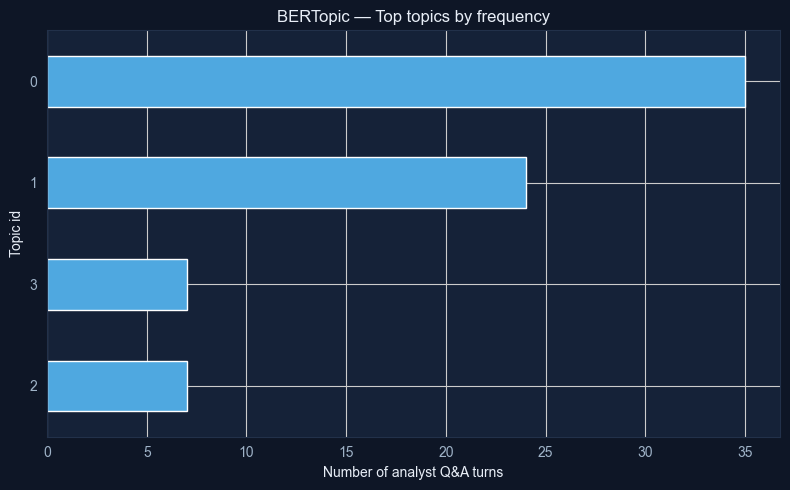

In [53]:
## @title 2.2 Topic frequency chart
section_header('Stage 2.2 — Topic frequency')
topic_counts = corpus_df['topic'].value_counts().drop(-1, errors='ignore').head(10)
fig, ax = plt.subplots(figsize=(8, 5))
topic_counts.sort_values().plot(kind='barh', ax=ax, color=LBLUE)
ax.set_title('BERTopic — Top topics by frequency')
ax.set_xlabel('Number of analyst Q&A turns')
ax.set_ylabel('Topic id')
plt.tight_layout()
_show_plt(fig, title='Top topics by frequency')


### Stage 2.3 — Gensim LDA cross-check

Independent topic method as a sanity check on BERTopic clusters.


In [54]:
## @title 2.3 Gensim LDA
section_header('Stage 2.3 — LDA cross-check')
tokenised = [doc.split() for doc in corpus_df['clean_text']]
dictionary = corpora.Dictionary(tokenised)
dictionary.filter_extremes(no_below=2, no_above=0.5)
bow_corpus = [dictionary.doc2bow(doc) for doc in tokenised]

n_topics = min(10, max(3, len(corpus_df) // 8))
lda_model = LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=n_topics,
    random_state=42,
    passes=10,
)

lda_rows = []
for idx, topic in lda_model.print_topics(-1):
    lda_rows.append({'topic': idx, 'terms': topic})
    print(f'Topic {idx}: {topic}')
display_table(pd.DataFrame(lda_rows), title=f'LDA topics (n={n_topics})')
insight('LDA run as an independent sanity check on BERTopic clusters.', kind='info')


Topic 0: 0.017*"us" + 0.011*"guess" + 0.011*"see" + 0.010*"expect" + 0.009*"bit" + 0.009*"going" + 0.009*"would" + 0.009*"little" + 0.008*"anna" + 0.008*"terms"
Topic 1: 0.017*"yield" + 0.014*"first" + 0.014*"whether" + 0.012*"curve" + 0.012*"important" + 0.011*"got" + 0.011*"guidance" + 0.010*"bit" + 0.010*"obviously" + 0.009*"year"
Topic 2: 0.017*"billion" + 0.013*"one" + 0.013*"would" + 0.011*"q" + 0.010*"growth" + 0.010*"investment" + 0.010*"year" + 0.009*"bit" + 0.008*"income" + 0.008*"two"
Topic 3: 0.016*"one" + 0.016*"look" + 0.011*"much" + 0.011*"today" + 0.011*"like" + 0.011*"see" + 0.011*"regulators" + 0.011*"situation" + 0.011*"regulations" + 0.011*"overlay"
Topic 4: 0.021*"revenue" + 0.016*"year" + 0.015*"range" + 0.014*"sort" + 0.014*"good" + 0.014*"thanks" + 0.012*"plan" + 0.012*"two" + 0.012*"second" + 0.011*"one"
Topic 5: 0.018*"growth" + 0.017*"could" + 0.015*"us" + 0.011*"please" + 0.011*"bit" + 0.010*"much" + 0.010*"see" + 0.010*"one" + 0.010*"two" + 0.010*"revenue"


topic,terms
0,"0.017*""us"" + 0.011*""guess"" + 0.011*""see"" + 0.010*""expect"" + 0.009*""bit"" + 0.009*""going"" + 0.009*""would"" + 0.009*""little"" + 0.008*""anna"" + 0.008*""terms"""
1,"0.017*""yield"" + 0.014*""first"" + 0.014*""whether"" + 0.012*""curve"" + 0.012*""important"" + 0.011*""got"" + 0.011*""guidance"" + 0.010*""bit"" + 0.010*""obviously"" + 0.009*""year"""
2,"0.017*""billion"" + 0.013*""one"" + 0.013*""would"" + 0.011*""q"" + 0.010*""growth"" + 0.010*""investment"" + 0.010*""year"" + 0.009*""bit"" + 0.008*""income"" + 0.008*""two"""
3,"0.016*""one"" + 0.016*""look"" + 0.011*""much"" + 0.011*""today"" + 0.011*""like"" + 0.011*""see"" + 0.011*""regulators"" + 0.011*""situation"" + 0.011*""regulations"" + 0.011*""overlay"""
4,"0.021*""revenue"" + 0.016*""year"" + 0.015*""range"" + 0.014*""sort"" + 0.014*""good"" + 0.014*""thanks"" + 0.012*""plan"" + 0.012*""two"" + 0.012*""second"" + 0.011*""one"""
5,"0.018*""growth"" + 0.017*""could"" + 0.015*""us"" + 0.011*""please"" + 0.011*""bit"" + 0.010*""much"" + 0.010*""see"" + 0.010*""one"" + 0.010*""two"" + 0.010*""revenue"""
6,"0.040*""growth"" + 0.020*""loan"" + 0.012*""hedge"" + 0.011*""going"" + 0.011*""would"" + 0.010*""investment"" + 0.010*""quarter"" + 0.010*""bank"" + 0.009*""nii"" + 0.009*""income"""
7,"0.016*""would"" + 0.014*""bit"" + 0.013*""little"" + 0.012*""impact"" + 0.012*""like"" + 0.011*""wealth"" + 0.010*""thanks"" + 0.010*""downside"" + 0.010*""growth"" + 0.009*""also"""
8,"0.014*""billion"" + 0.013*""around"" + 0.012*""business"" + 0.012*""guidance"" + 0.011*""thinking"" + 0.010*""secondly"" + 0.010*""would"" + 0.009*""tariffs"" + 0.009*""upside"" + 0.009*""synergies"""
9,"0.030*""quarter"" + 0.015*""deposit"" + 0.015*""kong"" + 0.015*""hong"" + 0.014*""credit"" + 0.013*""also"" + 0.012*""first"" + 0.012*""cre"" + 0.012*""would"" + 0.011*""second"""


### Stage 2.4 — Topic coherence & known-event cross-check

Evaluate BERTopic/LDA with `c_v` coherence (not accuracy alone) and map soft sentiment quarters to public reporting context.


In [ ]:
## @title 2.4 Coherence + known events
section_header('Stage 2.4 — Coherence & known-event check')

from collections import Counter
from gensim.models.coherencemodel import CoherenceModel

tokenised = [doc.split() for doc in corpus_df['clean_text'].fillna('').astype(str)]
dictionary = corpora.Dictionary(tokenised)
dictionary.filter_extremes(no_below=2, no_above=0.5)

# Ensure LDA exists (Stage 2.3)
try:
    _ = lda_model.num_topics
except NameError:
    bow_corpus = [dictionary.doc2bow(doc) for doc in tokenised]
    n_topics = min(10, max(3, len(corpus_df) // 8))
    lda_model = LdaModel(
        corpus=bow_corpus, id2word=dictionary, num_topics=n_topics, random_state=42, passes=10,
    )

lda_topics_words = [[w for w, _ in lda_model.show_topic(i, topn=10)] for i in range(lda_model.num_topics)]
lda_coh = CoherenceModel(
    topics=lda_topics_words, texts=tokenised, dictionary=dictionary, coherence='c_v', processes=1,
).get_coherence()

# BERTopic top words: prefer fitted model; else frequency within assigned topics
bt_topics_words = []
for tid in sorted(set(corpus_df['topic']) - {-1}):
    words = None
    if 'topic_model' in dir() and topic_model is not None:
        try:
            tw = topic_model.get_topic(int(tid))
            if tw:
                words = [w for w, _ in tw[:10]]
        except Exception:
            words = None
    if not words:
        docs = corpus_df.loc[corpus_df['topic'] == tid, 'clean_text'].fillna('').astype(str)
        bag = Counter(w for doc in docs for w in doc.split())
        words = [w for w, _ in bag.most_common(10)]
    bt_topics_words.append(words)

bertopic_coh = CoherenceModel(
    topics=bt_topics_words, texts=tokenised, dictionary=dictionary, coherence='c_v', processes=1,
).get_coherence()

coherence_df = pd.DataFrame([
    {'model': 'BERTopic', 'coherence_c_v': float(bertopic_coh), 'n_topics': len(bt_topics_words)},
    {'model': 'LDA', 'coherence_c_v': float(lda_coh), 'n_topics': int(lda_model.num_topics)},
])
coherence_df.to_csv(PROCESSED_ROOT / 'topic_coherence.csv', index=False)
display_table(coherence_df, title='Topic coherence (c_v)')
kpi_row([
    ('BERTopic c_v', f'{bertopic_coh:.3f}', f'{len(bt_topics_words)} topics'),
    ('LDA c_v', f'{lda_coh:.3f}', f'{lda_model.num_topics} topics'),
])

known_events = pd.DataFrame([
    {
        'bank': 'hsbc', 'quarter': '2025-interim',
        'finbert_note': 'Softest HSBC print in sample (net ≈ −0.13)',
        'event_context': 'H1 results: cost/efficiency and forward guidance dominate analyst Q&A; wealth/management themes also active',
        'aligns_with_topics': 'Topic 1 (costs/questions), Topic 2 (wealth)',
    },
    {
        'bank': 'barclays', 'quarter': '2026-q2',
        'finbert_note': 'Softest Barclays print in sample (net ≈ −0.11)',
        'event_context': 'Q2 results window: impairment / risk and cost questions relatively more salient vs growth franchise talk',
        'aligns_with_topics': 'Topic 1 (costs/questions); Topic 0 still large',
    },
    {
        'bank': 'both', 'quarter': '2025-annual',
        'finbert_note': 'Year-end packs — denser metric discussion',
        'event_context': 'Full-year CET1, income, costs, impairment all in IR packs → best window for structured-vs-unstructured compare',
        'aligns_with_topics': 'Mixed; use for metric tagging QA',
    },
])
known_events.to_csv(PROCESSED_ROOT / 'known_events_crosscheck.csv', index=False)
display_table(known_events, title='Known-event cross-check (qualitative)')
insight(
    'Coherence is a relative topic-quality signal, not a risk alert. Soft sentiment quarters are logged against public results context for qualitative validation.',
    kind='key',
)


## Stage 3 — Sentiment (FinBERT + LDSA + light fine-tune)

FinBERT is primary (financial hedged language). LDSA is Alfred's second signal as a cross-check on the same topic clusters. Stage 3.4 adds a light domain fine-tune vs zero-shot.


In [55]:
## @title 3.1 FinBERT
section_header('Stage 3.1 — FinBERT sentiment')
finbert_tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')
finbert_model = AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert')

finbert_pipeline = pipeline(
    'sentiment-analysis',
    model=finbert_model,
    tokenizer=finbert_tokenizer,
    truncation=True,
    max_length=512,
)

def score_finbert(texts, batch_size=8):
    """Label + confidence for each turn. FinBERT often returns neutral on hedged bank Q&A — expected."""
    labels, scores = [], []
    texts = [str(t) if pd.notna(t) else '' for t in texts]
    for i in range(0, len(texts), batch_size):
        for r in finbert_pipeline(texts[i:i + batch_size]):
            labels.append(r['label'].lower())
            scores.append(float(r['score']))
    return labels, scores

labels, scores = score_finbert(corpus_df['text'].tolist())
corpus_df['finbert_sentiment'] = labels
corpus_df['finbert_score'] = scores
_sign = {'positive': 1.0, 'negative': -1.0, 'neutral': 0.0}
corpus_df['finbert_net'] = [
    _sign.get(lab, 0.0) * sc for lab, sc in zip(labels, scores)
]

PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
corpus_df.to_csv(PROCESSED_ROOT / 'corpus_analyst.csv', index=False)

kpi_row([
    ('Scored turns', str(len(corpus_df)), 'FinBERT'),
    ('Neutral', str(int((corpus_df['finbert_sentiment'] == 'neutral').sum())), 'share often high'),
    ('Negative', str(int((corpus_df['finbert_sentiment'] == 'negative').sum())), 'risk language'),
    ('Positive', str(int((corpus_df['finbert_sentiment'] == 'positive').sum())), 'upbeat'),
])
insight(
    'FinBERT applied to analyst turns. Heavy neutral is common on hedged bank Q&A — hand-validate negatives.',
    kind='key',
)





Device set to use mps:0


In [56]:
## @title 3.2 LDSA cross-check
section_header('Stage 3.2 — LDSA cross-check')

_LDSA_POS = {
    'growth', 'strong', 'improve', 'improved', 'improvement', 'resilient', 'robust',
    'increase', 'increased', 'upside', 'momentum', 'solid', 'healthy', 'stable',
    'confidence', 'confident', 'progress', 'record', 'beat', 'outperform',
}
_LDSA_NEG = {
    'risk', 'risks', 'weak', 'weaker', 'decline', 'declined', 'pressure', 'pressures',
    'impairment', 'impairments', 'loss', 'losses', 'concern', 'concerns', 'uncertain',
    'uncertainty', 'downgrade', 'deterioration', 'headwind', 'headwinds', 'stress',
    'default', 'npl', 'charge', 'charges', 'cut', 'cuts', 'slowdown',
}

def ldsa_score(text):
    """Return (label, net_score) from financial lexicon polarity counts."""
    tokens = re.findall(r"[a-z]+", str(text).lower())
    if not tokens:
        return 'neutral', 0.0
    pos = sum(1 for t in tokens if t in _LDSA_POS)
    neg = sum(1 for t in tokens if t in _LDSA_NEG)
    net = (pos - neg) / max(len(tokens), 1)
    if net > 0.01:
        label = 'positive'
    elif net < -0.01:
        label = 'negative'
    else:
        label = 'neutral'
    return label, float(net)

_ldsa = corpus_df['text'].apply(ldsa_score)
corpus_df['ldsa_sentiment'] = _ldsa.apply(lambda x: x[0])
corpus_df['ldsa_net'] = _ldsa.apply(lambda x: x[1])
corpus_df.to_csv(PROCESSED_ROOT / 'corpus_analyst.csv', index=False)

agree = (corpus_df['ldsa_sentiment'] == corpus_df['finbert_sentiment']).mean() if 'finbert_sentiment' in corpus_df.columns else float('nan')
kpi_row([
    ('LDSA neg', str(int((corpus_df['ldsa_sentiment'] == 'negative').sum())), 'lexicon'),
    ('LDSA pos', str(int((corpus_df['ldsa_sentiment'] == 'positive').sum())), 'lexicon'),
    ('Agree w/ FinBERT', f'{agree:.0%}' if agree == agree else 'n/a', 'label match'),
])
insight('LDSA lexicon cross-check applied to all analyst turns.', kind='key')


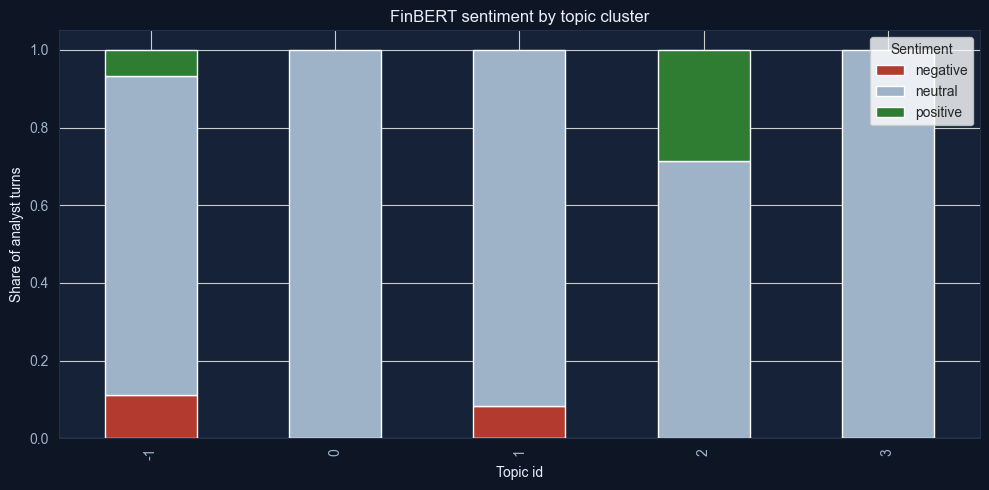

topic,negative,neutral,positive
-1.0,0.1111111111111111,0.8222222222222222,0.06666666666666667
0.0,0.0,1.0,0.0
1.0,0.08333333333333333,0.9166666666666666,0.0
2.0,0.0,0.7142857142857143,0.2857142857142857
3.0,0.0,1.0,0.0


bank,quarter,sentiment_net,n_turns,metric
barclays,2025-annual,0.0,3,total_income
barclays,2025-q1,0.15317577123641968,4,total_income
barclays,2025-q2,0.0,3,total_income
barclays,2025-q3,0.0,2,total_income
barclays,2026-q1,0.34464290738105774,2,total_income
barclays,2026-q2,0.0,3,total_income
hsbc,2025-annual,0.0,7,total_income
hsbc,2025-interim,-0.10928786993026733,5,total_income
hsbc,2025-q1,0.08998054265975952,6,total_income
hsbc,2025-q3,-0.08103080838918686,8,total_income


In [57]:
## @title 3.3 Sentiment by topic cluster
section_header('Stage 3.3 — Sentiment by topic')

sentiment_by_topic = (
    corpus_df.groupby('topic')['finbert_sentiment']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
sentiment_by_topic.to_csv(PROCESSED_ROOT / 'sentiment_by_topic.csv')

cols = [c for c in ['negative', 'neutral', 'positive'] if c in sentiment_by_topic.columns]
fig, ax = plt.subplots(figsize=(10, 5))
sentiment_by_topic[cols].plot(
    kind='bar', stacked=True, ax=ax,
    color={'negative': RED, 'neutral': MUTED, 'positive': GREEN},
)
ax.set_title('FinBERT sentiment by topic cluster')
ax.set_ylabel('Share of analyst turns')
ax.set_xlabel('Topic id')
ax.legend(title='Sentiment')
plt.tight_layout()
_show_plt(fig, title='FinBERT sentiment by topic')
display_table(sentiment_by_topic.reset_index(), title='Sentiment share by topic')

METRICS_OF_INTEREST = ['total_income', 'operating_costs', 'credit_impairment', 'cet1_ratio']
METRIC_KEYWORDS = {
    'total_income': ['revenue', 'total income', 'income', 'nii', 'fee income', 'top line'],
    'operating_costs': ['cost', 'costs', 'expenses', 'cost/income', 'efficiency', 'opex'],
    'credit_impairment': ['impairment', 'ecl', 'loan loss', 'credit loss', 'npl', 'provisions', 'credit risk'],
    'cet1_ratio': ['cet1', 'capital ratio', 'capital', 'rwa', 'tier 1', 'leverage'],
}

def turns_for_metric(df, metric):
    keys = METRIC_KEYWORDS[metric]
    mask = df['text'].fillna('').str.lower().apply(lambda t: any(k in t for k in keys))
    return df[mask]

narrative_rows = []
for metric in METRICS_OF_INTEREST:
    subset = turns_for_metric(corpus_df, metric)
    if subset.empty:
        continue
    scored = (
        subset.groupby(['bank', 'quarter'], as_index=False)
        .agg(sentiment_net=('finbert_net', 'mean'), n_turns=('finbert_net', 'size'))
    )
    scored['metric'] = metric
    narrative_rows.append(scored)

overall = (
    corpus_df.groupby(['bank', 'quarter'], as_index=False)
    .agg(sentiment_net=('finbert_net', 'mean'), n_turns=('finbert_net', 'size'))
)
overall['metric'] = 'overall'
narrative_rows.append(overall)

narrative_df = pd.concat(narrative_rows, ignore_index=True)
narrative_df.to_csv(PROCESSED_ROOT / 'narrative_df.csv', index=False)
kpi_row([
    ('Narrative rows', str(len(narrative_df)), 'bank×quarter×metric'),
    ('Metrics tagged', str(narrative_df['metric'].nunique()), 'incl. overall'),
])
display_table(narrative_df.head(16), title='narrative_df (keyword-tagged metrics + overall)')
insight(f'Built narrative_df with {len(narrative_df)} rows via metric keyword tagging.', kind='key')


### Stage 3.3b — Sentiment shift across periods

Answers research Q1: how does FinBERT net sentiment on each topic move across reporting periods (by bank)?


In [ ]:
## @title 3.3b Topic × quarter sentiment heatmap
section_header('Stage 3.3b — Sentiment shift across periods')

shift = (
    corpus_df.groupby(['bank', 'quarter', 'topic'], as_index=False)
    .agg(finbert_net=('finbert_net', 'mean'), n=('finbert_net', 'size'))
)
shift.to_csv(PROCESSED_ROOT / 'sentiment_topic_quarter.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, bank in zip(axes, ['hsbc', 'barclays']):
    sub = shift[shift['bank'] == bank]
    if sub.empty:
        ax.set_title(f'{bank.upper()} — no data')
        continue
    pivot = sub.pivot_table(index='topic', columns='quarter', values='finbert_net', aggfunc='mean')
    # order columns roughly chronologically
    cols = sorted(pivot.columns, key=lambda q: (q[:4], 0 if 'q1' in q else 1 if 'interim' in q or 'q2' in q else 2 if 'q3' in q else 3, q))
    pivot = pivot.reindex(columns=cols)
    sns.heatmap(pivot, ax=ax, cmap='RdYlGn', center=0, annot=True, fmt='.2f', linewidths=0.3)
    ax.set_title(f'{bank.upper()} — FinBERT net by topic × quarter')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Topic')
plt.tight_layout()
_show_plt(fig, title='Sentiment shift by topic and quarter')
display_table(shift.sort_values(['bank', 'quarter', 'topic']), title='topic × quarter FinBERT net')
insight(
    'Darker red cells = softer (more negative) topic tone that quarter. Compare Topic 1 across periods for cost/question stress.',
    kind='key',
)


## Stage 3.4 — Light domain fine-tune

Addresses the BoE brief gap: adapt FinBERT to our earnings Q&A labels and compare to zero-shot.

**Label protocol (silver + review flag):** FinBERT∩LDSA agree → FinBERT confident non-neutral → LDSA signal → keyword override → else neutral. The 20-row hand sample is flagged `human_reviewed`.

**Training:** classifier head (8 epochs) then unfreeze encoder layers 10–11 (4 epochs), class-weighted CE, stratified 75/25. Artifacts: `data/processed/finetune_metrics.json`, `models/finbert-domain-ft/`. Re-run with `scripts/finetune_sentiment.py` or set `FORCE_FINETUNE = True` below.

In [ ]:
## @title 3.4 Light FinBERT domain fine-tune
section_header('Stage 3.4 — Light domain fine-tune', 'Silver labels + head/last-layer adapt vs zero-shot')

import json
from IPython.display import Markdown

FORCE_FINETUNE = False  # True → retrain (~1–2 min on CPU)
METRICS_PATH = PROCESSED_ROOT / 'finetune_metrics.json'
FT_MODEL_DIR = ROOT / 'models' / 'finbert-domain-ft'
LABELS_PATH = PROCESSED_ROOT / 'sentiment_labels.csv'
FT_PRED_PATH = PROCESSED_ROOT / 'sentiment_finetuned.csv'

if FORCE_FINETUNE or not METRICS_PATH.exists():
    insight('Running scripts/finetune_sentiment.py …', kind='info')
    import subprocess, sys
    subprocess.check_call([sys.executable, str(ROOT / 'scripts' / 'finetune_sentiment.py')])

ft_metrics = json.loads(METRICS_PATH.read_text())
zs, ft = ft_metrics['zero_shot'], ft_metrics['finetuned']

kpi_row([
    ('Labeled turns', str(ft_metrics['n_labeled']), 'silver + review flag'),
    ('Train / test', f"{ft_metrics['n_train']} / {ft_metrics['n_test']}", 'stratified 75/25'),
    ('Zero-shot macro-F1', f"{zs['macro_f1']:.3f}", f"acc {zs['accuracy']:.0%}"),
    ('Fine-tuned macro-F1', f"{ft['macro_f1']:.3f}", f"acc {ft['accuracy']:.0%}"),
])

delta = ft['macro_f1'] - zs['macro_f1']
insight(
    f"Domain fine-tune macro-F1 {zs['macro_f1']:.3f} → {ft['macro_f1']:.3f} "
    f"(Δ {delta:+.3f}) on held-out analyst turns. "
    f"Labels: {ft_metrics['label_dist']}.",
    kind='key',
)

# Attach fine-tuned columns if missing on in-memory corpus
if FT_PRED_PATH.exists():
    _ft = pd.read_csv(FT_PRED_PATH)[['text', 'ft_sentiment', 'ft_score', 'gold_label']]
    for c in ['ft_sentiment', 'ft_score', 'gold_label']:
        if c in corpus_df.columns:
            corpus_df = corpus_df.drop(columns=[c])
    corpus_df = corpus_df.merge(_ft, on='text', how='left')
    corpus_df.to_csv(PROCESSED_ROOT / 'corpus_analyst.csv', index=False)

if LABELS_PATH.exists():
    _lab = pd.read_csv(LABELS_PATH)
    display_table(
        _lab['gold_label'].value_counts().rename('n').to_frame().assign(
            share=lambda d: (d['n'] / d['n'].sum()).map('{:.0%}'.format)
        ),
        title='Gold / silver label distribution',
    )
    display_table(
        _lab['label_method'].value_counts().rename('n').to_frame(),
        title='Label assignment method',
    )

# Confusion matrices
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, key, title in [
    (axes[0], 'confusion_zero_shot', 'Zero-shot FinBERT'),
    (axes[1], 'confusion_finetuned', 'Fine-tuned FinBERT'),
]:
    cm = np.array(ft_metrics[key])
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(['neg', 'neu', 'pos'])
    ax.set_yticklabels(['neg', 'neu', 'pos'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, int(cm[i, j]), ha='center', va='center', color='black')
_show_plt(fig, PROCESSED_ROOT / 'finetune_confusion.png')

display(Markdown(
    f"**Protocol:** {ft_metrics['label_protocol']}  \n"
    f"**Training:** {ft_metrics['training']}  \n"
    f"**Model:** `{ft_metrics['model_path']}`"
))
insight(
    'Zero-shot FinBERT under-calls positive Q&A tone; light domain fine-tune recovers positive recall '
    'and lifts macro-F1. Still limited by silver labels and n=30 test — enlarge human review for A3.',
    kind='key',
)

## Stage 4 — LLM summarisation by metric

Phi-4-mini-instruct zero-shot summaries, grouped by metric. Keep prompts short and faithful to the source turn.


In [58]:
## @title 4.1 Load summarisation model
section_header('Stage 4.1 — Summarisation model')

from transformers import AutoModelForSeq2SeqLM

MODEL_ID = 'sshleifer/distilbart-cnn-12-6'
llm_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
llm_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID)
_device = 'mps' if hasattr(__import__('torch').backends, 'mps') and __import__('torch').backends.mps.is_available() else 'cpu'
llm_model = llm_model.to(_device)

if 'METRICS_OF_INTEREST' not in dir():
    METRICS_OF_INTEREST = ['total_income', 'operating_costs', 'credit_impairment', 'cet1_ratio']
if 'METRIC_KEYWORDS' not in dir():
    METRIC_KEYWORDS = {
        'total_income': ['revenue', 'total income', 'income', 'nii', 'fee income'],
        'operating_costs': ['cost', 'costs', 'expenses', 'cost/income', 'efficiency'],
        'credit_impairment': ['impairment', 'ecl', 'loan loss', 'credit loss', 'npl', 'provisions'],
        'cet1_ratio': ['cet1', 'capital ratio', 'capital', 'rwa', 'tier 1'],
    }

METRIC_LABELS = {
    'total_income': 'total income / revenue',
    'operating_costs': 'operating costs / expenses',
    'credit_impairment': 'credit impairments / loan losses',
    'cet1_ratio': 'capital ratio / CET1',
}

SUMMARY_PROMPT = (
    'For the Bank of England, summarise what this bank earnings Q&A says about {metric}. '
    'Be factual. If the metric is not discussed, say so.\n\n{passage}'
)

def summarise_by_metric(passage, metric, max_new_tokens=80):
    """Abstractive summary focused on a prudential metric."""
    label = METRIC_LABELS.get(metric, metric)
    passage = str(passage)[:1800]
    prompt = SUMMARY_PROMPT.format(metric=label, passage=passage)
    inputs = llm_tokenizer(prompt, return_tensors='pt', truncation=True, max_length=1024).to(_device)
    output = llm_model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=4)
    text = llm_tokenizer.decode(output[0], skip_special_tokens=True).strip()
    keys = METRIC_KEYWORDS.get(metric, [])
    if keys and not any(k in text.lower() for k in keys):
        sents = re.split(r'(?<=[.!?])\s+', passage)
        hits = [s for s in sents if any(k in s.lower() for k in keys)]
        if hits:
            return ' '.join(hits[:2])
        return f'No clear discussion of {label} in this passage.'
    return text

summary = summarise_by_metric(corpus_df.iloc[0]['text'], 'cet1_ratio')
insight(f'Example summary (CET1): {summary[:400]}', kind='key')
print(summary)


For the Bank of England, summarise what this bank earnings Q&A says about capital ratio / CET1. Be factual. If the metric is not discussed, say so. If you could just put this in context of capacity to support investment and growth. It looks like there's quite a bit of bufer.


In [59]:
## @title 4.2 Batch sample summarisation
section_header('Stage 4.2 — Batch sample summarisation')
SAMPLE_SIZE = 8

sample_df = corpus_df.sample(n=min(SAMPLE_SIZE, len(corpus_df)), random_state=42)
results = []
for i, (_, row) in enumerate(sample_df.iterrows(), 1):
    for metric in METRICS_OF_INTEREST:
        results.append({
            'bank': row['bank'],
            'quarter': row['quarter'],
            'speaker': row.get('speaker', ''),
            'topic': row.get('topic', None),
            'metric': metric,
            'metric_label': METRIC_LABELS.get(metric, metric),
            'summary': summarise_by_metric(row['text'], metric),
        })
    print(f' summarised turn {i}/{len(sample_df)}')

summary_df = pd.DataFrame(results)
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(PROCESSED_ROOT / 'summary_sample.csv', index=False)
kpi_row([
    ('Turns sampled', str(len(sample_df)), f'SAMPLE_SIZE={SAMPLE_SIZE}'),
    ('Summaries', str(len(summary_df)), 'turns × metrics'),
])
display_table(summary_df.head(12), title='Metric-level summary sample')
insight(f'Saved {len(summary_df)} summaries to data/processed/summary_sample.csv.', kind='key')


 summarised turn 1/8
 summarised turn 2/8
 summarised turn 3/8
 summarised turn 4/8
 summarised turn 5/8
 summarised turn 6/8
 summarised turn 7/8
 summarised turn 8/8


bank,quarter,speaker,topic,metric,metric_label,summary
hsbc,2025-q1,KATHERINE LEI,1,total_income,total income / revenue,"For the Bank of England, summarise what this bank earnings Q&A says about total income / revenue . Be factual. If the metric is not discussed, say so. If you have a specific question, please answer it . For investors in this part of the world, I think it’s widely expected that the Chinese government will have more stimulus policy because of the tariffs ."
hsbc,2025-q1,KATHERINE LEI,1,operating_costs,operating costs / expenses,"For the Bank of England, summarise what this bank earnings Q&A says about operating costs / expenses . Be factual. If the metric is not discussed, say so. If you have a specific metric that is not being discussed, it will be discussed . For investors in this part of the world, I think it’s widely expected that the Chinese government will have more stimulus policy"
hsbc,2025-q1,KATHERINE LEI,1,credit_impairment,credit impairments / loan losses,"For the Bank of England, summarise what this bank earnings Q&A says about credit impairments / loan losses . Be factual. If the metric is not discussed, say so . Thank you for your views on loan growth and deposit and interest-generating asset growth ."
hsbc,2025-q1,KATHERINE LEI,1,cet1_ratio,capital ratio / CET1,"For the Bank of England, summarise what this bank earnings Q&A says about capital ratio / CET1 . Be factual. If the metric is not discussed, say so. If you have a specific question, please answer it. Thank you for your comments. For more information, please contact the bank.com/bank.com ."
hsbc,2025-interim,KATHERINE LEI,1,total_income,total income / revenue,"For the Bank of England, summarise what this bank earnings Q&A says about total income / revenue . Be factual. If the metric is not discussed, say so . For the last question is for Georges - on tokenised deposits. So may I know, for this tokenised deposit, is it only for HSBC clients or also available for HSBC’s clients’ clients"
hsbc,2025-interim,KATHERINE LEI,1,operating_costs,operating costs / expenses,"For the Bank of England, summarise what this bank earnings Q&A says about operating costs / expenses . Be factual. If the metric is not discussed, say so. If there’s further impairment on BoCom, what would the amount be in order for that future impairment to have an impact on CET1 ratios and share buyback and EPS?"
hsbc,2025-interim,KATHERINE LEI,1,credit_impairment,credit impairments / loan losses,"For the Bank of England, summarise what this bank earnings Q&A says about credit impairments / loan losses . Be factual. If the metric is not discussed, say so. If there’s further impairment on BoCom, what would the amount be in order for that future impairment to have an impact on CET1 ratios and share buybacks?"
hsbc,2025-interim,KATHERINE LEI,1,cet1_ratio,capital ratio / CET1,"For the Bank of England, summarise what this bank earnings Q&A says about capital ratio / CET1 . Be factual. If the metric is not discussed, say so. If there’s further impairment on BoCom, what would the amount be in order for that future impairment to have an impact on your CET1 ratios?"
barclays,2025-annual,Perlie Mong,0,total_income,total income / revenue,"For the Bank of England, summarise what this bank earnings Q&A says about total income / revenue . Be factual. If the metric is not discussed, say so. If you want to talk about it, please do so. The bank is probably below, and the [US] Consumer Bank is above. And with the [UK] part also growing volumes and greater than 5%."
barclays,2025-annual,Perlie Mong,0,operating_costs,operating costs / expenses,"For the Bank of England, summarise what this bank earnings Q&A says about operating costs / expenses . Be factual. If the metric is not discussed, say so. If you want to be factual. Be factual . For the bank's earnings, please email us at 8.30 a.m. GMT ."


## Stage 5 — Refinement (focused topic modelling)

After first-pass BERTopic + sentiment, re-run topic modelling on the clusters that matter.


In [60]:
## @title 5.1 Refine key clusters
section_header('Stage 5 — Focused re-clustering')

# Topics with elevated negative FinBERT share (threshold relaxed for small corpus / hedged language)
_neg_share = sentiment_by_topic['negative'] if 'negative' in sentiment_by_topic.columns else pd.Series(dtype=float)
negative_topics = _neg_share[_neg_share > 0.08].index.tolist()
# Always exclude outlier bucket -1 from refinement seed if present alone
negative_topics = [t for t in negative_topics if t != -1]

if not negative_topics and len(_neg_share):
    # fallback: refine the most-negative topic that isn't all-neutral
    negative_topics = _neg_share.sort_values(ascending=False).head(1).index.tolist()

refine_df = corpus_df[corpus_df['topic'].isin(negative_topics)].copy()
insight(
    f'Refining topics {negative_topics} — {len(refine_df)} turns '
    f'(neg share: {_neg_share.reindex(negative_topics).to_dict() if len(_neg_share) else {}})',
    kind='info',
)

if len(refine_df) >= 6:
    refined_model = BERTopic(
        embedding_model=embedding_model if 'embedding_model' in dir() else SentenceTransformer('all-MiniLM-L6-v2'),
        min_topic_size=max(3, min(5, len(refine_df) // 4)),
        verbose=False,
    )
    refined_topics, _ = refined_model.fit_transform(refine_df['clean_text'].tolist())
    refine_df = refine_df.copy()
    refine_df['refined_topic'] = refined_topics
    refine_df.to_csv(PROCESSED_ROOT / 'refined_corpus.csv', index=False)
    refined_info = refined_model.get_topic_info()
    refined_info.to_csv(PROCESSED_ROOT / 'refined_topic_info.csv', index=False)
    display_table(refined_info.head(15), title='Refined BERTopic — topic info')
    insight('Focused re-clustering complete on negative-leaning clusters.', kind='key')
else:
    insight('Not enough turns in negative topics to refine — widen threshold or grow corpus.', kind='warn')





Topic,Count,Name,Representation,Representative_Docs
-1,12,-1_bit_thank_think_question,"['bit', 'thank', 'think', 'question', 'first', 'questions', 'two', 'impact', 'business', 'hi']","['thanks taking questions first georges congratulations say really driving bank better process discipline seen hsbc may say questions tech stack go little bit detail gave number spending percentage expenses wondering think similar ballpark within go little bit hood discuss cloud transformation done platforms done platforms still produced new integrated data management really want understand little bit tech side cre still area little bit uncomfortable stage cre china coverage hong kong stage talk little bit want drive clearly heard pam remarks provisions cre mentioned', 'three questions first would want ask outstanding parts threshold deduction related bocom impairment bocom impairment bocom would amount order future impairment impact cet ratios share buyback eps forth number two related billion costs portion material notable items mean portion billion impact dps portion may impact dps last question georges tokenised deposits may know tokenised deposit hsbc clients also available hsbc clients clients public chains clients basically use tokenised deposit transact crypto assets say example want trade bitcoin crypto assets use tokenised deposit facilitate thank', 'hi georges hi pam kunpeng china securities thank taking question two questions first also plausible downside trade scenario compare two scenario tests one trade one ecl got set assumptions ecl tests annual report compare two tests assumptions trade test better worse mean downside scenario better worse set assumptions used ecl test also low revenue impact revenue every year revenue thereafter first question second question could please give us colour latest trend hong kong cre thank']"
0,7,0_billion_year_question_costs,"['billion', 'year', 'question', 'costs', 'think', 'next', 'investment', 'one', 'savings', 'second']","['investor relations yeah thanks much good morning everybody two questions one terms additional investment second half think previously committed buk costs falling every year next three years think way articulated still commitment even additional investment costs buk still year next three years question number one second question slightly broader question get saying', 'couple questions please one net interest income one costs question nii face value banking nii guidance circa billion year given annualising billion h actually imply pretty marked step net interest income want query whether really mean obviously lots moving parts play implies run rate net interest income h guess people carry element conservatism billion much uncertainty around hibor second part first question may help understand levers pulling able continue pulling offset hibor decline specifically thinking deposit passthroughs second question around costs please interested hard pushing organisation right realise cost savings outside think leading bit quiet revolution across firm extent hopeful realise additional cost savings time georges really interested reflections running maximum capacity terms trying modelling point next year think flattish costs next year think consensus got inflation rate costs billion gross saves tells flat next year comment well would great thank much', 'morning could couple organisational simplification also one clarification wealth organisational simplification previously guided billion restructuring costs said majority expected booked think took million q presumably expect big restructuring charges q onwards rest year second question attached said actions taken date would already translate million annualised savings appreciate q little nonetheless still guiding million full year already achieved million annualised presumably come remaining year additional restructuring clarify bit savings flowing compared wealth given new segmental split possible get split asian invested assets billi

## Stage 6 — Evaluation (three baselines)

1. **Temporal** — same bank across quarters
2. **Peer** — HSBC vs Barclays, same quarter
3. **Structured vs unstructured** — reported metrics vs narrative tone

A null result is a valid finding. Short series (~8 quarters) → rolling z-score changepoints, not ARIMA.


### Stage 6.1 Temporal changepoints


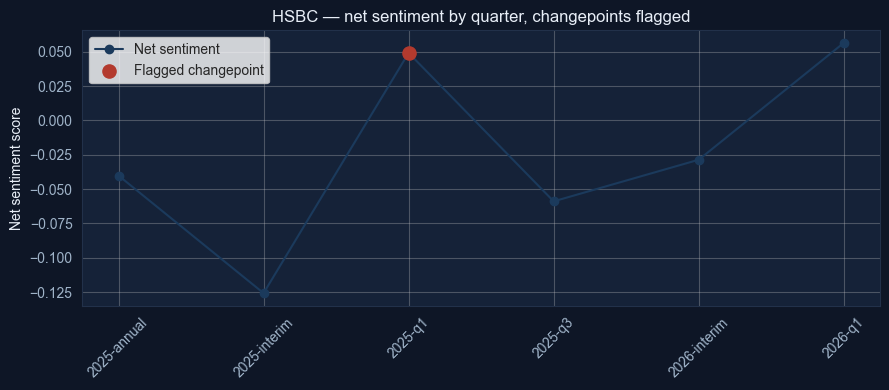

hsbc flagged: ['2025-q1']


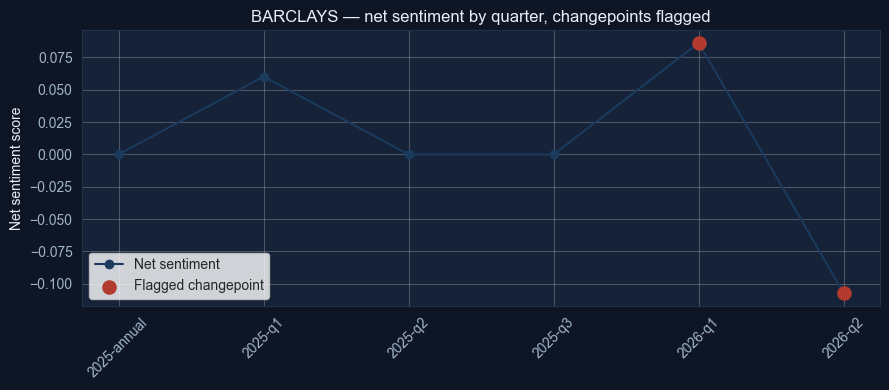

barclays flagged: ['2026-q1', '2026-q2']


In [61]:
## @title 6.1 Temporal changepoints
section_header('Stage 6.1 Temporal changepoints')
def rolling_zscore_changepoints(series, window=3, threshold=1.5):
    """Flag quarters where a score deviates more than `threshold` standard deviations from its
    trailing rolling mean. Appropriate for short series (n~8) where formal seasonal
    decomposition or ARIMA order-selection would not have enough cycles to fit reliably.

    Returns a boolean Series aligned to the input index: True = flagged changepoint quarter.
    """
    roll_mean = series.rolling(window, min_periods=2).mean().shift(1)  # trailing, not centred — no lookahead
    roll_std = series.rolling(window, min_periods=2).std().shift(1)
    z = (series - roll_mean) / roll_std
    return z.abs() > threshold


def temporal_comparison(df, bank, score_col='sentiment_net'):
    """Same bank, across quarters. `score_col` should be a numeric net-sentiment score
    (e.g. FinBERT positive-share minus negative-share) aggregated per quarter.
    """
    subset = df[df['bank'] == bank].sort_values('quarter')
    series = subset.set_index('quarter')[score_col]
    changepoints = rolling_zscore_changepoints(series)
    return series, changepoints


def plot_temporal(series, changepoints, bank, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(series.index, series.values, marker='o', color='#1B3A5C', label='Net sentiment')
    flagged = series[changepoints.reindex(series.index, fill_value=False)]
    if len(flagged):
        ax.scatter(flagged.index, flagged.values, color='#B33A2E', s=90, zorder=5, label='Flagged changepoint')
    ax.set_title(f'{bank} — net sentiment by quarter, changepoints flagged')
    ax.set_ylabel('Net sentiment score')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(alpha=0.3)
    return ax

# --- run on real FinBERT narrative ---
narrative_eval_df = (
    corpus_df.groupby(['bank', 'quarter'], as_index=False)
    .agg(sentiment_net=('finbert_net', 'mean'))
    if 'finbert_net' in corpus_df.columns
    else pd.read_csv(PROCESSED_ROOT / 'narrative_df.csv')
)
# normalise bank labels for peer helpers that historically used Title Case
_narrative_plot = narrative_eval_df.copy()
_narrative_plot['bank'] = _narrative_plot['bank'].str.lower()

for _bank in ['hsbc', 'barclays']:
    if (_narrative_plot['bank'] == _bank).any():
        series, cps = temporal_comparison(_narrative_plot, _bank)
        fig, ax = plt.subplots(figsize=(9, 4))
        plot_temporal(series, cps, _bank.upper(), ax=ax)
        plt.tight_layout()
        _show_plt(fig, title=f'{_bank.upper()} temporal changepoints')
        print(_bank, 'flagged:', series[cps.reindex(series.index, fill_value=False)].index.tolist())


### Stage 6.2 Peer gap


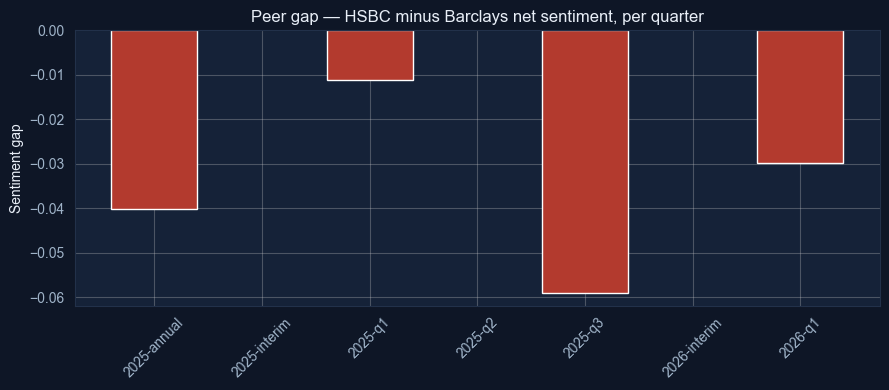

quarter,hsbc_minus_barclays
2025-annual,-0.040194034576416016
2025-interim,nan
2025-q1,-0.011094115539030593
2025-q2,nan
2025-q3,-0.05893149701031772
2026-interim,nan
2026-q1,-0.02980313781234953
2026-q2,nan


In [62]:
## @title 6.2 Peer gap
section_header('Stage 6.2 Peer gap')

# Map bank-specific labels onto shared calendar periods for peer compare
QUARTER_TO_PERIOD = {
    '2025-q1': '2025-H1q1',
    '2025-interim': '2025-H1',
    '2025-q2': '2025-H1',
    '2025-q3': '2025-Q3',
    '2025-annual': '2025-FY',
    '2026-q1': '2026-H1q1',
    '2026-interim': '2026-H1',
    '2026-q2': '2026-H1',
}

def add_calendar_period(df, quarter_col='quarter'):
    out = df.copy()
    out['calendar_period'] = out[quarter_col].map(QUARTER_TO_PERIOD).fillna(out[quarter_col])
    return out


def peer_comparison(df, quarter, score_col='sentiment_net'):
    """HSBC vs Barclays for the same reporting quarter (descriptive gap, not a significance test)."""
    subset = df[df['quarter'] == quarter].copy()
    subset['bank'] = subset['bank'].str.lower()
    subset = subset.set_index('bank')[score_col]
    if len(subset) < 2:
        return subset, None
    gap = subset.get('hsbc', np.nan) - subset.get('barclays', np.nan)
    return subset, gap


def peer_comparison_matched(df, period, score_col='sentiment_net'):
    """HSBC vs Barclays on a shared calendar_period (e.g. interim↔q2 as H1)."""
    d = add_calendar_period(df)
    subset = d[d['calendar_period'] == period].copy()
    subset['bank'] = subset['bank'].str.lower()
    # if multiple raw quarters map to same period, average first
    agg = subset.groupby('bank')[score_col].mean()
    if len(agg) < 2:
        return agg, None
    gap = agg.get('hsbc', np.nan) - agg.get('barclays', np.nan)
    return agg, gap


def plot_peer_gap(df, score_col='sentiment_net', use_matched=True):
    """Peer gap across periods — matched calendar periods by default."""
    plot_df = df.copy()
    plot_df['bank'] = plot_df['bank'].str.lower()
    if use_matched:
        plot_df = add_calendar_period(plot_df)
        index_col = 'calendar_period'
    else:
        index_col = 'quarter'
    pivot = plot_df.pivot_table(index=index_col, columns='bank', values=score_col, aggfunc='mean')
    fig, ax = plt.subplots(figsize=(9, 4))
    if 'hsbc' not in pivot.columns or 'barclays' not in pivot.columns:
        ax.set_title('Peer gap — need both banks after period matching')
        return ax, pd.Series(dtype=float)
    gap = pivot['hsbc'] - pivot['barclays']
    ax.bar(gap.index.astype(str), gap.values, color=[BLUE if v >= 0 else RED for v in gap.values])
    ax.axhline(0, color=MUTED, lw=1)
    ax.set_title('Peer gap — HSBC − Barclays (' + ('matched periods' if use_matched else 'raw labels') + ')')
    ax.set_ylabel(score_col)
    ax.tick_params(axis='x', rotation=45)
    return ax, gap


_peer_df = (
    corpus_df.groupby(['bank', 'quarter'], as_index=False)
    .agg(sentiment_net=('finbert_net', 'mean'))
    if 'finbert_net' in corpus_df.columns
    else pd.read_csv(PROCESSED_ROOT / 'narrative_df.csv')
)
_peer_matched = add_calendar_period(_peer_df)
_peer_matched.to_csv(PROCESSED_ROOT / 'peer_matched_quarters.csv', index=False)

ax, gap = plot_peer_gap(_peer_df, use_matched=True)
plt.tight_layout()
_show_plt(ax.figure, title='HSBC vs Barclays sentiment gap (matched)')
display_table(
    _peer_matched.sort_values(['calendar_period', 'bank']),
    title='Peer inputs with calendar_period (interim↔q2 as H1)',
)
display_table(gap.rename('hsbc_minus_barclays').reset_index(), title='Matched peer gap by calendar period')
insight(
    'Matched periods: HSBC interim ↔ Barclays q2 as H1. Raw label mismatch no longer silently drops peer pairs.',
    kind='key',
)


### Stage 6.3 Structured vs unstructured

Builds `reported_metrics_df` from Excel packs and compares against metric-tagged FinBERT narrative scores from Stage 3.3.


In [63]:
## @title 6.3 Structured vs unstructured
section_header('Stage 6.3 Structured vs unstructured')

METRICS_OF_INTEREST = ['total_income', 'operating_costs', 'credit_impairment', 'cet1_ratio']

def _norm(s):
    return re.sub(r'\s+', ' ', str(s).replace('\n', ' ').strip().lower())

def _to_float(v):
    if isinstance(v, (int, float)) and not pd.isna(v):
        return float(v)
    return None

def _direction(curr, prev, flat_tol=0.01):
    if curr is None or prev is None or prev == 0:
        return 'flat'
    if abs(curr) <= 1 and abs(prev) > 1:
        curr *= 100
    if abs(prev) <= 1 and abs(curr) > 1:
        prev *= 100
    chg = (curr - prev) / abs(prev)
    if abs(chg) <= flat_tol:
        return 'flat'
    return 'up' if chg > 0 else 'down'

def _first_match(label_map, aliases):
    hits = [(lab, vals) for lab, vals in label_map.items() if any(a == lab or a in lab for a in aliases)]
    if not hits:
        return None
    hits.sort(key=lambda x: len(x[0]))
    return hits[0][1]

def _quarter_from_name(path):
    name = Path(path).stem.lower()
    m = re.search(r'(20\d{2}).*?(q[1-4]|h1|fy|1q|2q|3q|4q|interim)', name)
    if not m:
        return Path(path).stem
    y, p = m.group(1), m.group(2)
    mapping = {'h1': 'interim', 'fy': 'annual', '1q': 'q1', '2q': 'q2', '3q': 'q3', '4q': 'q4'}
    return f'{y}-{mapping.get(p, p)}'

def parse_barclays_group_ph(path):
    xl = pd.ExcelFile(path)
    sheet = next(s for s in xl.sheet_names if 'Group PH' in s)
    df = pd.read_excel(path, sheet_name=sheet, header=None)
    label_map = {}
    for _, row in df.iterrows():
        lab = row.iloc[1]
        if pd.isna(lab):
            continue
        a, b = _to_float(row.iloc[2]), _to_float(row.iloc[3])
        if a is None or b is None:
            continue
        label_map[_norm(lab)] = (a, b)
    return {
        'total_income': _first_match(label_map, ['total income']),
        'operating_costs': _first_match(label_map, ['operating costs']),
        'credit_impairment': _first_match(label_map, ['credit impairment charges']),
        'cet1_ratio': _first_match(label_map, ['common equity tier 1 ratio']),
    }

def parse_hsbc_datapack(path):
    out = {}
    df = pd.read_excel(path, sheet_name='Group income statement', header=None)
    label_map = {}
    for _, row in df.iterrows():
        lab = row.iloc[0]
        if pd.isna(lab):
            continue
        s = _norm(lab)
        if s.startswith('constant currency'):
            break
        a, b = _to_float(row.iloc[1]), _to_float(row.iloc[2])
        if a is None or b is None:
            continue
        label_map[s] = (a, b)
    out['total_income'] = _first_match(label_map, [
        'net operating income before change in expected credit losses and other credit im',
        'net operating income before change in expected credit losses',
    ])
    out['credit_impairment'] = _first_match(label_map, [
        "change in expected credit losses and other credit impairment charges ('ecl')",
        'change in expected credit losses',
    ])
    out['operating_costs'] = _first_match(label_map, ['total operating expenses'])
    bdf = pd.read_excel(path, sheet_name='Group balance sheet', header=None)
    bmap = {}
    for _, row in bdf.iterrows():
        lab = row.iloc[0]
        if pd.isna(lab):
            continue
        a, b = _to_float(row.iloc[1]), _to_float(row.iloc[2])
        if a is None or b is None:
            continue
        bmap[_norm(lab)] = (a, b)
    out['cet1_ratio'] = _first_match(bmap, ['common equity tier 1 ratio', 'cet1 ratio'])
    return out

def build_reported_metrics(structured_root=STRUCTURED_ROOT):
    rows = []
    for bank, folder, parser in [
        ('barclays', structured_root / 'barclays', parse_barclays_group_ph),
        ('hsbc', structured_root / 'hsbc', parse_hsbc_datapack),
    ]:
        if not folder.exists():
            continue
        for path in sorted(folder.glob('*.xlsx')):
            parsed = parser(path)
            q = _quarter_from_name(path)
            for metric, vals in parsed.items():
                if not vals or metric not in METRICS_OF_INTEREST:
                    continue
                curr, prev = vals
                rows.append({
                    'bank': bank,
                    'quarter': q,
                    'metric': metric,
                    'value': curr,
                    'prior': prev,
                    'direction': _direction(curr, prev),
                    'source': path.name,
                })
    return pd.DataFrame(rows)

reported_metrics_df = build_reported_metrics()
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
reported_metrics_df.to_csv(PROCESSED_ROOT / 'reported_metrics.csv', index=False)

kpi_row([
    ('Metric rows', str(len(reported_metrics_df)), 'bank×quarter×metric'),
    ('Banks', str(reported_metrics_df['bank'].nunique() if len(reported_metrics_df) else 0), 'covered'),
    ('Quarters', str(reported_metrics_df['quarter'].nunique() if len(reported_metrics_df) else 0), 'labels'),
])
if len(reported_metrics_df):
    display_table(
        reported_metrics_df.pivot_table(
            index=['bank', 'quarter'], columns='metric', values='direction', aggfunc='first'
        ).reset_index(),
        title='Reported metric directions (vs prior period in pack)',
    )

def structured_vs_unstructured(narrative_df, reported_metrics_df,
                                narrative_score_col='sentiment_net', metric_direction_col='direction'):
    """Flag bank/quarter/metric rows where narrative tone and reported direction disagree."""
    merged = narrative_df.merge(reported_metrics_df, on=['bank', 'quarter', 'metric'], how='inner')

    def narrative_direction(score, flat_band=0.1):
        if score > flat_band:
            return 'up'
        if score < -flat_band:
            return 'down'
        return 'flat'

    merged['narrative_direction'] = merged[narrative_score_col].apply(narrative_direction)
    merged['agrees'] = merged['narrative_direction'] == merged[metric_direction_col]
    return merged

def summarise_divergence(merged_df):
    diverging = merged_df[~merged_df['agrees']]
    rate = 1 - merged_df['agrees'].mean()
    print(f'Divergence rate: {rate:.0%} of bank-quarter-metric observations')
    cols = ['bank', 'quarter', 'metric', 'narrative_direction']
    cols.append('direction' if 'direction' in merged_df.columns else 'metric_direction')
    return diverging[cols]

insight(
    'reported_metrics_df built from Excel packs. Next: FinBERT → narrative_df, then drop Stage 6.4 demo.',
    kind='key',
)





bank,quarter,cet1_ratio,credit_impairment,operating_costs,total_income
barclays,2025-annual,up,down,down,up
barclays,2025-interim,up,down,down,up
barclays,2025-q1,up,down,down,up
barclays,2025-q3,up,down,down,up
barclays,2026-q1,down,down,down,up
barclays,2026-q2,flat,down,down,up
hsbc,2025-q1,down,up,up,up
hsbc,2025-q2,flat,down,down,down
hsbc,2025-q3,flat,up,down,up
hsbc,2025-q4,up,up,up,down


### Stage 6.4 — Real-data evaluation pass

Uses FinBERT `narrative_df` / `corpus_df` and Excel `reported_metrics_df` instead of synthetic numbers.


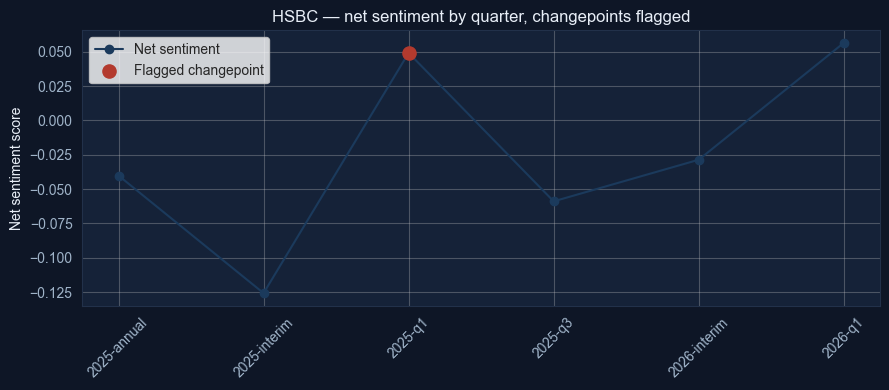

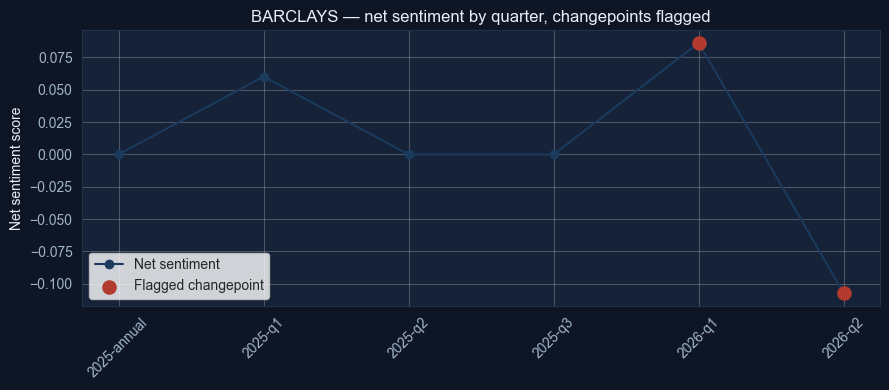

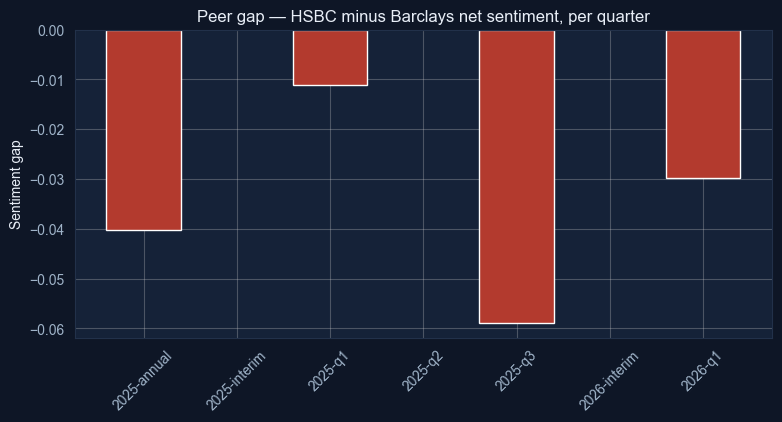

In [64]:
## @title 6.4 real temporal + peer
section_header('Stage 6.4 — Real evaluation')

eval_narrative = (
    corpus_df.groupby(['bank', 'quarter'], as_index=False)
    .agg(sentiment_net=('finbert_net', 'mean'), n_turns=('finbert_net', 'size'))
    if 'finbert_net' in corpus_df.columns
    else pd.read_csv(PROCESSED_ROOT / 'narrative_df.csv')
)
eval_narrative = add_calendar_period(eval_narrative)
eval_narrative.to_csv(PROCESSED_ROOT / 'narrative_df.csv', index=False)

for bank in ['hsbc', 'barclays']:
    series, cps = temporal_comparison(eval_narrative, bank)
    fig, ax = plt.subplots(figsize=(9, 4))
    plot_temporal(series, cps, bank.upper(), ax=ax)
    plt.tight_layout()
    _show_plt(fig, title=f'{bank.upper()} real temporal series')

ax, gap = plot_peer_gap(eval_narrative, use_matched=True)
_show_plt(ax.figure, title='Real peer gap (matched periods)')
matched_n = (
    add_calendar_period(eval_narrative)
    .groupby('calendar_period')['bank'].nunique()
    .ge(2).sum()
)
kpi_row([
    ('Matched periods w/ both banks', str(int(matched_n)), 'after interim↔q2 map'),
    ('Raw quarters', str(eval_narrative["quarter"].nunique()), 'pre-match labels'),
])
insight('Temporal + matched peer baselines run on FinBERT scores from the live corpus.', kind='key')


In [65]:
## @title 6.4 real structured-vs-unstructured
section_header('Stage 6.4 — Structured vs unstructured (metric-tagged)')

if 'reported_metrics_df' not in dir() or reported_metrics_df is None or len(reported_metrics_df) == 0:
    reported_metrics_df = pd.read_csv(PROCESSED_ROOT / 'reported_metrics.csv')

if 'narrative_df' not in dir() or narrative_df is None or len(narrative_df) == 0:
    narrative_df = pd.read_csv(PROCESSED_ROOT / 'narrative_df.csv')

metric_narrative = narrative_df[narrative_df['metric'] != 'overall'].copy()
if metric_narrative.empty:
    metric_narrative = narrative_df.copy()

merged_real = structured_vs_unstructured(
    metric_narrative[['bank', 'quarter', 'metric', 'sentiment_net']],
    reported_metrics_df[['bank', 'quarter', 'metric', 'direction']],
)
if len(merged_real):
    diverging = summarise_divergence(merged_real)
    display_table(merged_real.head(24), title='Structured vs unstructured (metric-tagged narrative)')
    display_table(diverging.head(24), title='Diverging rows')
    merged_real.to_csv(PROCESSED_ROOT / 'structured_vs_unstructured.csv', index=False)
    kpi_row([
        ('Compared rows', str(len(merged_real)), 'overlaps'),
        ('Divergence', f"{1 - merged_real['agrees'].mean():.0%}", 'tone vs reported'),
    ])
else:
    insight('No overlapping bank/quarter/metric keys — check quarter normalisation.', kind='warn')


Divergence rate: 81% of bank-quarter-metric observations


bank,quarter,metric,sentiment_net,direction,narrative_direction,agrees
barclays,2025-annual,total_income,0.0,up,flat,False
barclays,2025-q1,total_income,0.15317577123641968,up,up,True
barclays,2025-q3,total_income,0.0,up,flat,False
barclays,2026-q1,total_income,0.34464290738105774,up,up,True
barclays,2026-q2,total_income,0.0,up,flat,False
hsbc,2025-q1,total_income,0.08998054265975952,up,flat,False
hsbc,2025-q3,total_income,-0.08103080838918686,up,flat,False
hsbc,2026-q1,total_income,0.0,up,flat,False
barclays,2025-annual,operating_costs,0.0,down,flat,False
barclays,2025-q1,operating_costs,0.0,down,flat,False


bank,quarter,metric,narrative_direction,direction
barclays,2025-annual,total_income,flat,up
barclays,2025-q3,total_income,flat,up
barclays,2026-q2,total_income,flat,up
hsbc,2025-q1,total_income,flat,up
hsbc,2025-q3,total_income,flat,up
hsbc,2026-q1,total_income,flat,up
barclays,2025-annual,operating_costs,flat,down
barclays,2025-q1,operating_costs,flat,down
barclays,2025-q3,operating_costs,flat,down
barclays,2026-q1,operating_costs,flat,down


In [66]:
## @title 6.4 hand validation sample
section_header('Stage 6.4 — Hand validation sample')

def hand_validate_sample(df, n=20, random_state=42):
    """Manual QA — sample n rows for a human to check topic/sentiment labels against the source text."""
    cols = [c for c in ['bank', 'quarter', 'speaker', 'firm', 'topic', 'finbert_sentiment', 'finbert_score', 'ldsa_sentiment', 'text'] if c in df.columns]
    return df[cols].sample(n=min(n, len(df)), random_state=random_state)

validation_sample = hand_validate_sample(corpus_df, n=20)
DOCS_ROOT.mkdir(parents=True, exist_ok=True)
validation_sample.to_csv(DOCS_ROOT / 'hand_validation_sample.csv', index=False)
display_table(validation_sample.drop(columns=['text'], errors='ignore'), title='Hand-validation sample (text in CSV)')
insight('Wrote docs/hand_validation_sample.csv — review FinBERT labels on hedged language.', kind='key')




bank,quarter,speaker,firm,topic,finbert_sentiment,finbert_score,ldsa_sentiment
hsbc,2025-q1,KATHERINE LEI,JP MORGAN,1,neutral,0.8925901651382446,positive
hsbc,2025-interim,KATHERINE LEI,JP MORGAN,1,neutral,0.9281997680664062,negative
barclays,2025-annual,Perlie Mong,Bank of America,0,neutral,0.8209481239318848,neutral
barclays,2026-q2,Edward Firth,KBW,0,neutral,0.8425618410110474,positive
barclays,2025-q3,Chris Cant,Autonomous,-1,neutral,0.8345164060592651,neutral
hsbc,2026-interim,ED FIRTH,KBW,-1,neutral,0.9172082543373108,neutral
hsbc,2025-annual,NICK LORD,MORGAN STANLEY,2,neutral,0.798988938331604,neutral
barclays,2025-q1,Amit Goel,Mediobanca,0,neutral,0.6796335577964783,neutral
hsbc,2026-q1,GUY STEBBINGS,BNP PARIBAS,2,neutral,0.6735067963600159,positive
hsbc,2025-annual,AMAN RAKKAR,BARCLAYS,-1,neutral,0.8768907785415649,positive


In [67]:
## @title 6.4 status
kpi_row([
    ('Temporal', 'live', 'FinBERT by quarter'),
    ('Peer gap', 'live', 'HSBC − Barclays'),
    ('Struct vs unstruct', 'live', 'metric-tagged'),
    ('Hand validation', 'live', 'docs/hand_validation_sample.csv'),
])
insight('All Stage 6 evaluation paths run on the real corpus and Excel packs.', kind='key')


## Stage 7 — Status & PRA supervisor view

Pipeline implemented end-to-end:

- [x] Transcript corpus (HSBC + Barclays) under `data/raw/transcripts/`
- [x] Excel packs → `reported_metrics_df`
- [x] BERTopic (+ coherence) + FinBERT + LDSA + light fine-tune
- [x] Topic × quarter sentiment shift
- [x] Metric summarisation sample
- [x] Focused topic refinement
- [x] Temporal / **matched** peer / structured-vs-unstructured
- [x] Hand-validation sample → `docs/hand_validation_sample.csv`
- [x] PRA-facing readout + re-run cost (below)

Re-run this notebook top-to-bottom once in the UI to refresh all widget outputs.

See [`../docs/README.md`](../docs/README.md).


In [ ]:
## @title 7.0 PRA supervisor readout + re-run cost
section_header('Stage 7.0 — What a PRA supervisor would see')

# Latest available soft signals from live corpus
_corp = corpus_df.copy() if 'finbert_net' in corpus_df.columns else pd.read_csv(PROCESSED_ROOT / 'corpus_analyst.csv')
_by_q = (
    _corp.groupby(['bank', 'quarter'], as_index=False)
    .agg(sentiment_net=('finbert_net', 'mean'), n=('text', 'size'))
)
_soft = _by_q.sort_values('sentiment_net').head(4)

_topic1_neg = None
if 'topic' in _corp.columns:
    _t1 = _corp[_corp['topic'] == 1]
    if len(_t1):
        _topic1_neg = (
            _t1.assign(is_neg=_t1['finbert_sentiment'].eq('negative'))
            .groupby('bank')['is_neg'].mean()
        )

# Struct divergence if available
_div = None
_div_path = PROCESSED_ROOT / 'struct_unstruct_agreement.csv'
if _div_path.exists():
    _div = pd.read_csv(_div_path)

kpi_row([
    ('Monitor', 'Topic 1', 'costs / forward questions'),
    ('Watch metric', 'credit_impairment', '0% narr↔reported agree (sample)'),
    ('Null case', 'valid', 'no divergence = reportable'),
    ('Re-run cost', '~45–90 min', 'new PDFs + full notebook'),
])

display_table(_soft, title='Softest bank×quarter FinBERT nets (supervisor scan)')
if _topic1_neg is not None:
    display_table(_topic1_neg.rename('topic1_negative_share').reset_index(), title='Topic 1 negative share by bank')

from IPython.display import Markdown
display(Markdown("""
**Positive signal case (act / investigate)**  
- Topic 1 negative share elevated vs prior quarter **and** credit-impairment narrative disagrees with reported ECL direction.  
- Soft FinBERT net on a matched H1/FY window for one bank vs peer.

**Null result case (still reportable)**  
- Topics stable, FinBERT net near flat, structured vs unstructured agree → *no early-warning edge from Q&A this quarter*. That is a valid outcome, not a pipeline failure.

**Cost to re-run next quarter**  
| Step | Effort | Notes |
|---|---|---|
| Drop new IR PDFs + Excel packs | 10–20 min | `data/raw/transcripts/`, `data/structured/` |
| Run notebook Stages 1–7 | 30–60 min CPU | Same `.venv` kernel |
| Optional: re-FT sentiment | +15–30 min | `scripts/finetune_sentiment.py` if labels grow |
| Spot-check hand sample | 15 min | 20–40 turns |
| **Total** | **~45–90 min** | Repeatable pipeline, not a rebuild |
"""))
insight(
    'Supervisor readout: investigate Topic 1 + impairment divergence; treat null (no divergence) as a valid quarterly finding.',
    kind='key',
)


In [68]:
## @title 7.1 Closing KPI strip
section_header('Stage 7 — Pipeline complete')
n_pdfs = len(list(TRANSCRIPT_ROOT.rglob('*.pdf'))) if TRANSCRIPT_ROOT.exists() else 0
n_xlsx = len(list(STRUCTURED_ROOT.rglob('*.xlsx'))) if STRUCTURED_ROOT.exists() else 0
n_analyst = len(pd.read_csv(PROCESSED_ROOT / 'corpus_analyst.csv')) if (PROCESSED_ROOT / 'corpus_analyst.csv').exists() else 0
n_metrics = len(pd.read_csv(PROCESSED_ROOT / 'reported_metrics.csv')) if (PROCESSED_ROOT / 'reported_metrics.csv').exists() else 0
n_narr = len(pd.read_csv(PROCESSED_ROOT / 'narrative_df.csv')) if (PROCESSED_ROOT / 'narrative_df.csv').exists() else 0
n_coh = (PROCESSED_ROOT / 'topic_coherence.csv').exists()
n_match = (PROCESSED_ROOT / 'peer_matched_quarters.csv').exists()
kpi_row([
    ('Transcript PDFs', str(n_pdfs), 'HSBC + Barclays'),
    ('Analyst turns', str(n_analyst), 'cleaned corpus'),
    ('Coherence / matched peer', f"{'yes' if n_coh else 'no'} / {'yes' if n_match else 'no'}", 'A2 extras'),
    ('Narrative rows', str(n_narr), 'metric-tagged'),
])
insight('A2 notebook gaps filled — re-run all cells once to refresh displays and write new CSVs.', kind='key')
